# Scoring the 2025 Projections Against What Actually Happened

Cal Raleigh finished the 2025 regular season with **60 home runs in 705 plate
appearances over 159 games** - the most ever by a catcher and the most ever by a
switch-hitter.

This notebook loads the simulated season totals produced by
`01-beta-binomial.ipynb` and `02-hierarchical-model.ipynb` and compares each
model's projection against that actual total. Run those two notebooks first;
they write their posterior simulations to `data/processed/`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('..')
from src.processing import CAL_RALEIGH_2025_ACTUAL
from src.visualization import plot_hr_pmf, plot_actual_vs_predictions

sns.set_style("whitegrid")

ACTUAL_HR = CAL_RALEIGH_2025_ACTUAL['HR']
ACTUAL_PA = CAL_RALEIGH_2025_ACTUAL['PA']
print(f"Actual 2025 line: {ACTUAL_HR} HR in {ACTUAL_PA} PA over {CAL_RALEIGH_2025_ACTUAL['G']} games")

Actual 2025 line: 60 HR in 705 PA over 159 games


In [2]:
from pathlib import Path

processed_dir = Path('../data/processed')
beta = np.load(processed_dir / 'beta_binomial_simulations.npz')
hier = np.load(processed_dir / 'hierarchical_simulations.npz')

# Ordered from least to most information about the 2025 season itself.
predictions = {
    'Hierarchical - base\n(ISO, Barrel%, HardHit%)': hier['base'],
    'Hierarchical - expanded\n(+ SLG, Med%, BB%, Age)': hier['expanded'],
    'Beta-binomial - career prior\n(pre-2025 stats only)': beta['career_prior'],
    'Beta-binomial - Bayesian update\n(2025 stats through 08-19)': beta['bayesian_update'],
}

for name, samples in predictions.items():
    label = name.replace('\n', ' ')
    print(f"{label}: median {np.median(samples):.0f}, "
          f"95% CI [{np.percentile(samples, 2.5):.0f}, {np.percentile(samples, 97.5):.0f}]")

Hierarchical - base (ISO, Barrel%, HardHit%): median 29, 95% CI [19, 40]
Hierarchical - expanded (+ SLG, Med%, BB%, Age): median 31, 95% CI [21, 43]
Beta-binomial - career prior (pre-2025 stats only): median 36, 95% CI [23, 51]
Beta-binomial - Bayesian update (2025 stats through 08-19): median 60, 95% CI [53, 68]


## Actual total vs. each model's projection

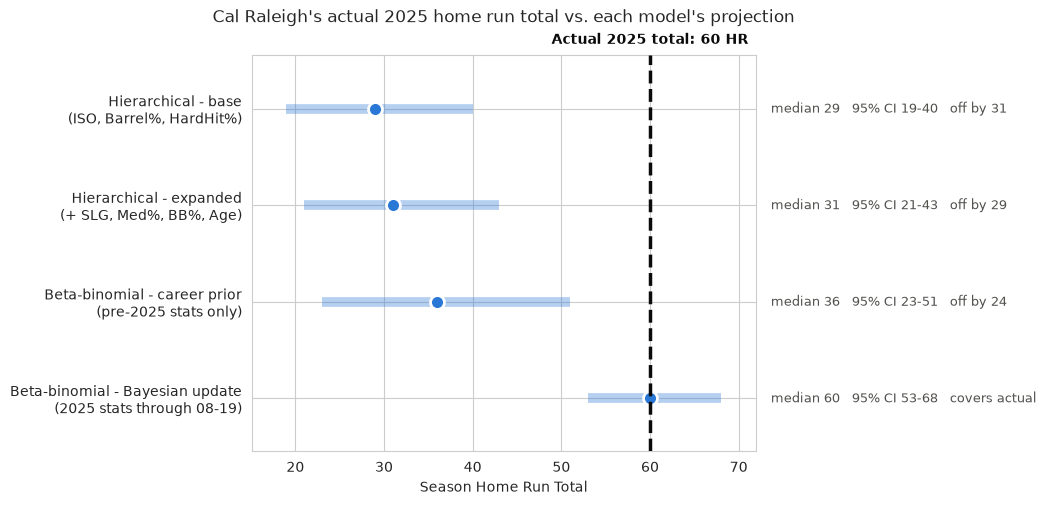

In [3]:
plot_actual_vs_predictions(
    predictions,
    actual=ACTUAL_HR,
    title="Cal Raleigh's actual 2025 home run total vs. each model's projection",
)
plt.savefig('../figures/actual-vs-predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## How much probability did each model put on 60+ home runs?

The forest plot above shows where each projection sat; this shows how far into
each model's tail the real answer landed.

P(season HR >= 60) under each model

  Hierarchical - base (ISO, Barrel%, HardHit%)                 0.0000
  Hierarchical - expanded (+ SLG, Med%, BB%, Age)              0.0000
  Beta-binomial - career prior (pre-2025 stats only)           0.0027
  Beta-binomial - Bayesian update (2025 stats through 08-19)   0.5367


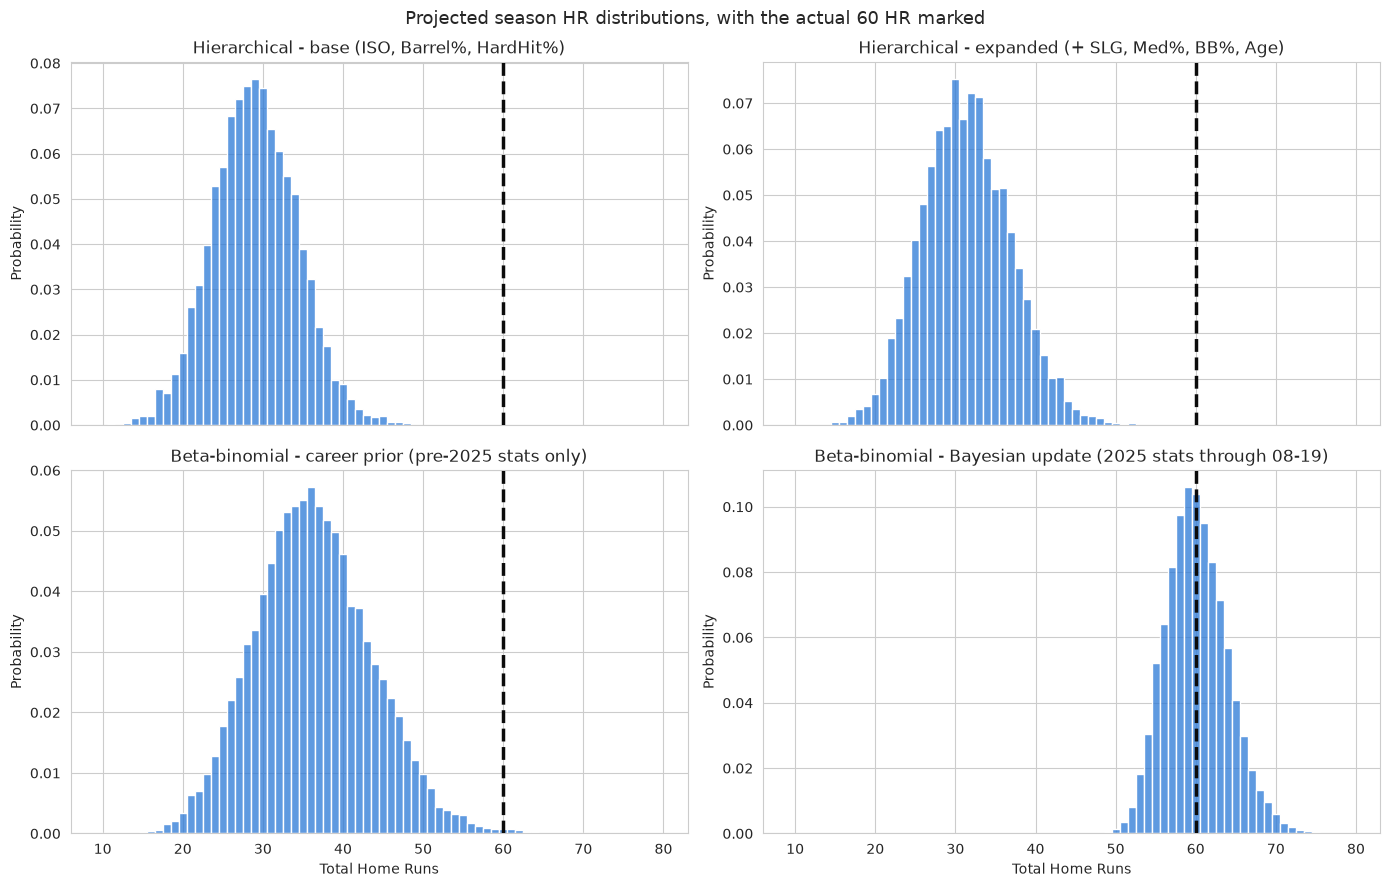

In [4]:
print(f"P(season HR >= {ACTUAL_HR}) under each model\n")
for name, samples in predictions.items():
    p = np.mean(samples >= ACTUAL_HR)
    print(f"  {name.replace(chr(10), ' '):<58} {p:>8.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for ax, (name, samples) in zip(axes.ravel(), predictions.items()):
    plot_hr_pmf({name.replace(chr(10), ' '): samples},
                title=name.replace('\n', ' '), actual=ACTUAL_HR, ax=ax, kde=False)
    ax.get_legend().remove()
fig.suptitle(f"Projected season HR distributions, with the actual {ACTUAL_HR} HR marked",
             fontsize=13)
plt.tight_layout()
plt.show()